# Task 3 — Scelta della granularità temporale per EvoMine

**Autore:** Carlo Invernizzi
**Tema:** Profili evolutivi multilivello di reti complesse tramite temporal network motif

---

## Obiettivo

Prima di far girare EvoMine sul campione CollegeMsg (5000 eventi, già preparato in
`output_data/collegemsg_sample_5000.txt`), è necessario scegliere una granularità
temporale con cui discretizzare i timestamp in bucket.

Questo notebook fa due analisi complementari per motivare la scelta:

1. **Distribuzione oraria** — quanti eventi cadono in ciascuna ora del periodo osservato,
   per vedere se ci sono pattern di attività (picchi diurni/notturni, giorni più attivi).
2. **Distribuzione degli inter-event time (IET)** — quanto tempo passa tra un evento e
   il successivo, per capire quale finestra di bucket cattura la maggior parte delle
   sequenze temporali senza comprimere troppo gli eventi insieme.

Infine viene prodotta una tabella comparativa di granularità candidate (30min, 1h, 6h,
12h, 1 giorno) per supportare la decisione finale.

### Output prodotti
```
output_png/collegemsg_hourly_distribution.png
output_png/collegemsg_iet_distribution.png
output_data/granularity_summary.txt
```


---
## 1. Import e caricamento del campione

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'

TASK3_DIR   = Path('/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3')
SAMPLE_FILE = TASK3_DIR / 'output_data' / 'collegemsg_sample_5000.txt'
OUT_PNG     = TASK3_DIR / 'output_png'
OUT_DATA    = TASK3_DIR / 'output_data'

OUT_PNG.mkdir(parents=True, exist_ok=True)
OUT_DATA.mkdir(parents=True, exist_ok=True)

print('Sample:', SAMPLE_FILE)
print('Output PNG:', OUT_PNG)
print('Output data:', OUT_DATA)

Sample: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data/collegemsg_sample_5000.txt
Output PNG: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_png
Output data: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data


In [2]:
# Il file ha colonne "src dst timestamp" (stesso formato usato in task_1/task_2,
# non "timestamp src dst" come edge list temporale SNAP).
df = pd.read_csv(SAMPLE_FILE, sep=' ', header=None, names=['src', 'dst', 'timestamp'])
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Eventi caricati: {len(df):,}')
print(f'Periodo: {df["datetime"].min()}  →  {df["datetime"].max()}')
print(f'Durata:  {(df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]) / 86400:.2f} giorni')
df.head()

Eventi caricati: 5,000
Periodo: 2004-04-15 14:56:01  →  2004-05-01 04:08:19
Durata:  15.55 giorni


,src,dst,timestamp,datetime
0,1,2,1082040961,2004-04-15 14:56:01
1,3,4,1082155839,2004-04-16 22:50:39
2,5,2,1082414391,2004-04-19 22:39:51
3,6,7,1082439619,2004-04-20 05:40:19
4,8,7,1082439756,2004-04-20 05:42:36


---
## ANALISI 1 — Distribuzione temporale per granularità oraria

Aggreghiamo gli eventi per ora (troncando il timestamp all'ora, es. `2004-04-15 14:00`)
e contiamo quanti messaggi cadono in ciascuna ora. Le ore senza eventi vengono incluse
con conteggio 0, in modo da vedere anche i periodi di inattività (es. notti).

In [3]:
df['hour_bucket'] = df['datetime'].dt.floor('h')
hourly_counts = df.groupby('hour_bucket').size()

# Reindicizza sull'intervallo completo di ore, cosi' i buchi (nessun evento) appaiono come 0
full_hour_range = pd.date_range(hourly_counts.index.min(), hourly_counts.index.max(), freq='h')
hourly_counts = hourly_counts.reindex(full_hour_range, fill_value=0)

print(f'Numero di ore nel periodo: {len(hourly_counts):,}')
print(f'Eventi/ora — media: {hourly_counts.mean():.1f}, mediana: {hourly_counts.median():.1f}, max: {hourly_counts.max()}')
print(f'Ore senza alcun evento: {(hourly_counts == 0).sum()} / {len(hourly_counts)} ({(hourly_counts == 0).mean()*100:.1f}%)')

Numero di ore nel periodo: 375
Eventi/ora — media: 13.3, mediana: 2.0, max: 151
Ore senza alcun evento: 159 / 375 (42.4%)


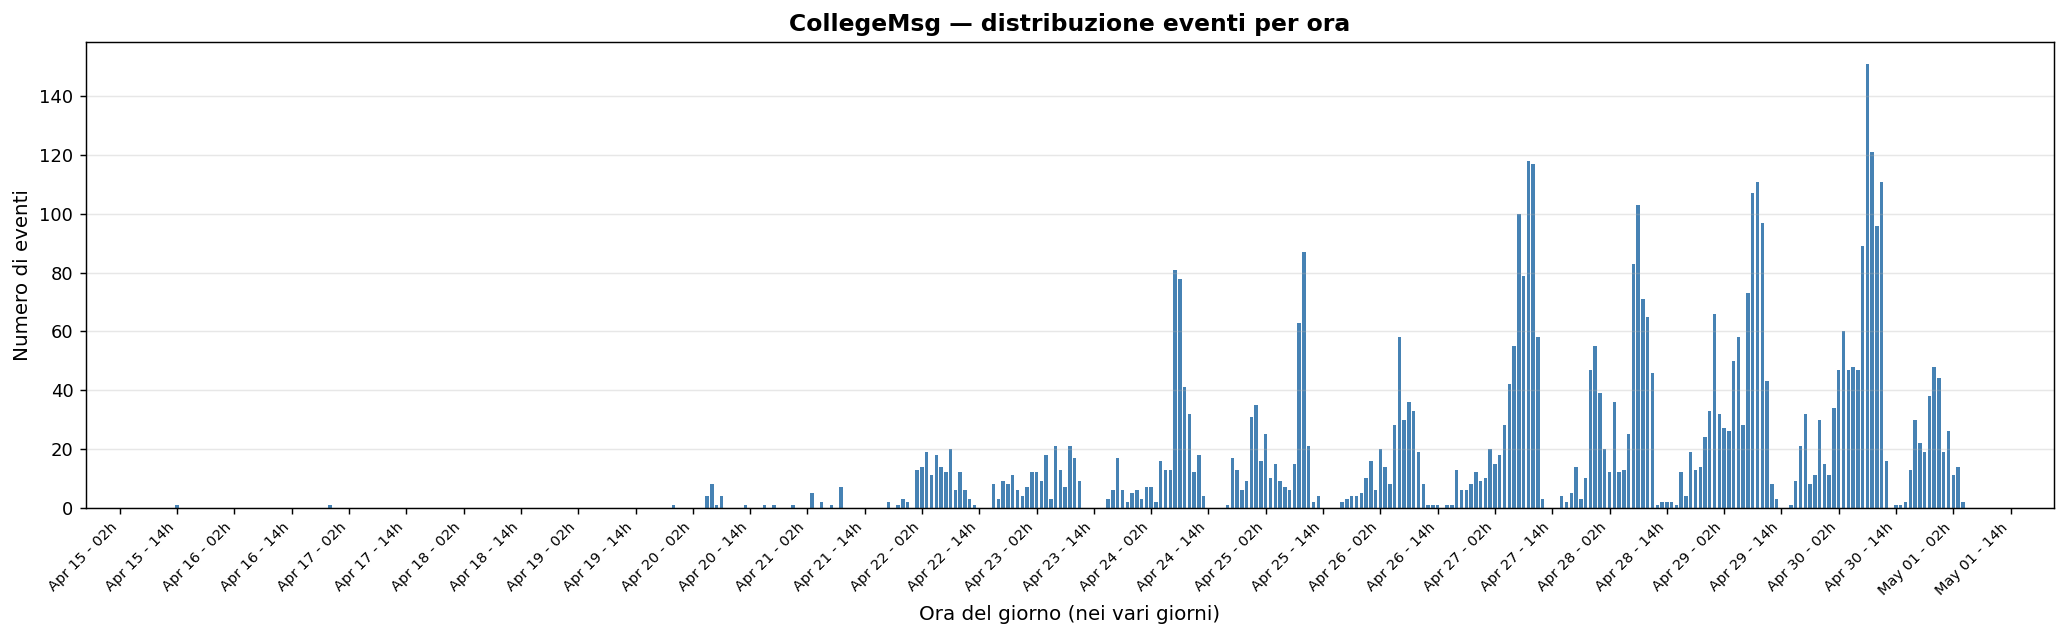

Salvato: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_png/collegemsg_hourly_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.bar(hourly_counts.index, hourly_counts.values, width=0.03,
       color='steelblue', edgecolor='none')

ax.set_title('CollegeMsg — distribuzione eventi per ora', fontsize=13, fontweight='bold')
ax.set_xlabel('Ora del giorno (nei vari giorni)', fontsize=11)
ax.set_ylabel('Numero di eventi', fontsize=11)

# Tick ogni 12 ore, formattati come "Apr 15 - 14h"
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d - %Hh'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

hourly_png = OUT_PNG / 'collegemsg_hourly_distribution.png'
plt.savefig(hourly_png, dpi=130)
plt.show()

print(f'Salvato: {hourly_png}')

---
## ANALISI 2 — Distribuzione degli inter-event time (IET)

Ordiniamo gli eventi per timestamp e calcoliamo le differenze consecutive
(`t[i+1] - t[i]`), in secondi. Questo misura quanto tempo passa tra un messaggio
e il successivo nell'intero campione (indipendentemente dai nodi coinvolti).

In [5]:
timestamps = df['timestamp'].sort_values().to_numpy()
iet_all = np.diff(timestamps)

n_zero = int(np.sum(iet_all == 0))
iet = iet_all[iet_all > 0]  # escludiamo eventi simultanei (delta_t = 0)

print(f'Differenze consecutive calcolate: {len(iet_all):,}')
print(f'Di cui delta_t = 0 (eventi simultanei): {n_zero:,}')
print(f'delta_t > 0 utilizzati per l\'analisi: {len(iet):,}')

REF = {
    '1 ora':   3600,
    '6 ore':   21600,
    '12 ore':  43200,
    '1 giorno': 86400,
}
REF_COLORS = ['#E74C3C', '#F39C12', '#27AE60', '#8E44AD']

Differenze consecutive calcolate: 4,999
Di cui delta_t = 0 (eventi simultanei): 29
delta_t > 0 utilizzati per l'analisi: 4,970


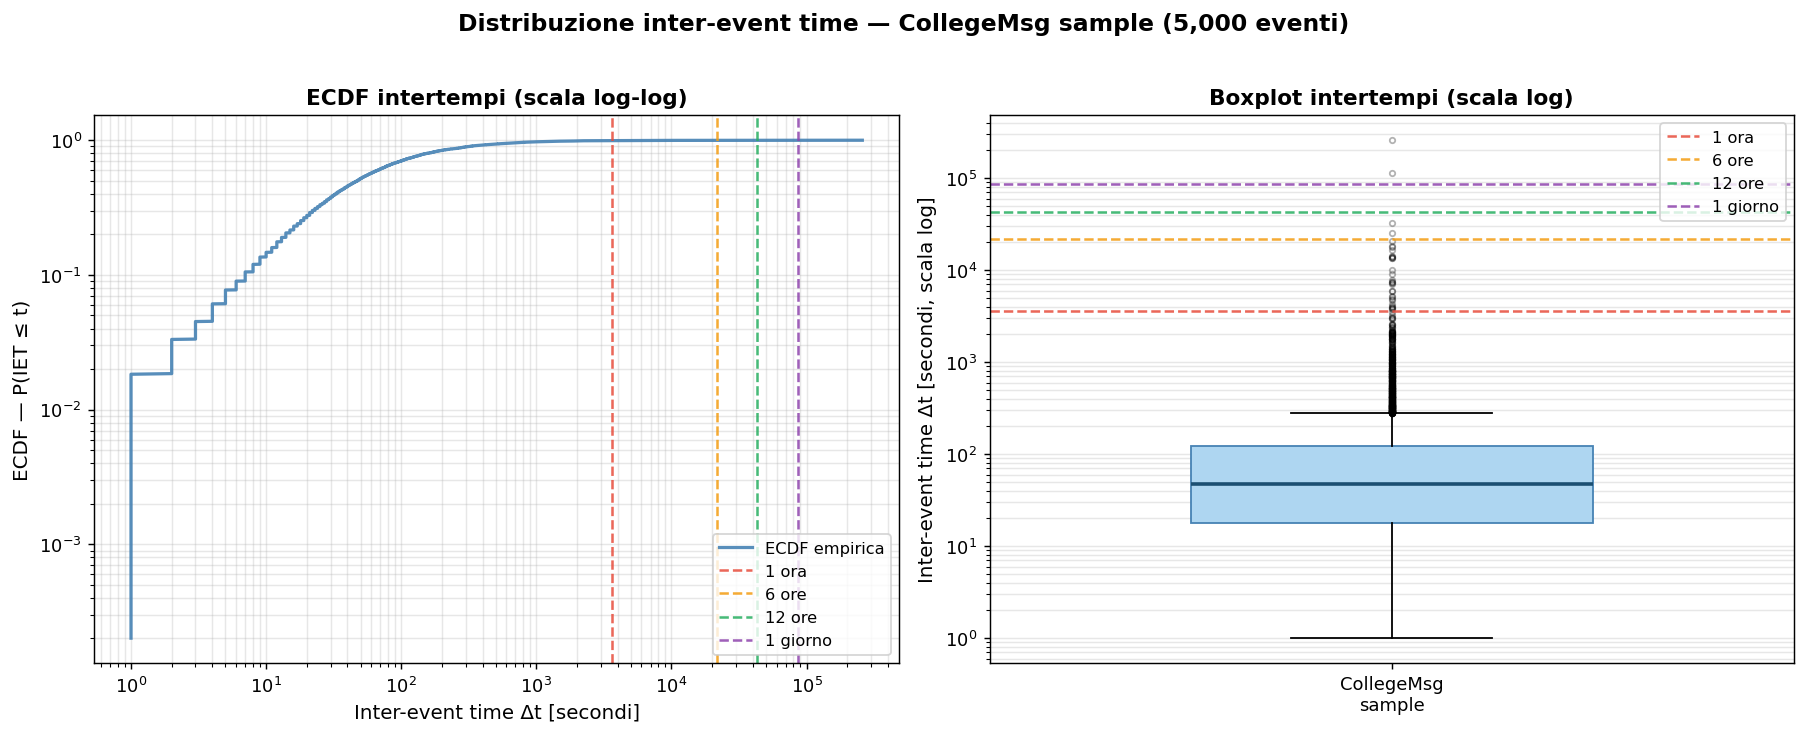

Salvato: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_png/collegemsg_iet_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Pannello sinistro: ECDF in scala log-log ---
ax = axes[0]
iet_sorted = np.sort(iet)
ecdf = np.arange(1, len(iet_sorted) + 1) / len(iet_sorted)

ax.plot(iet_sorted, ecdf, color='steelblue', lw=1.8, alpha=0.9, label='ECDF empirica')
ax.set_xscale('log')
ax.set_yscale('log')

for (label, secs), col in zip(REF.items(), REF_COLORS):
    if secs <= iet_sorted[-1]:
        ax.axvline(secs, color=col, linestyle='--', linewidth=1.4, alpha=0.85, label=label)

ax.set_xlabel('Inter-event time Δt [secondi]', fontsize=11)
ax.set_ylabel('ECDF — P(IET ≤ t)', fontsize=11)
ax.set_title('ECDF intertempi (scala log-log)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, which='both', alpha=0.3)

# --- Pannello destro: boxplot in scala logaritmica ---
ax2 = axes[1]
ax2.boxplot(iet, vert=True, widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor='#AED6F1', color='steelblue'),
            medianprops=dict(color='#1B4F72', linewidth=2),
            flierprops=dict(marker='o', markersize=3, alpha=0.3, color='gray'))
ax2.set_yscale('log')

for (label, secs), col in zip(REF.items(), REF_COLORS):
    if secs <= iet.max():
        ax2.axhline(secs, color=col, linestyle='--', linewidth=1.4, alpha=0.85, label=label)

ax2.set_ylabel('Inter-event time Δt [secondi, scala log]', fontsize=11)
ax2.set_xticklabels(['CollegeMsg\nsample'])
ax2.set_title('Boxplot intertempi (scala log)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, which='both', axis='y', alpha=0.3)

plt.suptitle(f'Distribuzione inter-event time — CollegeMsg sample ({len(df):,} eventi)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

iet_png = OUT_PNG / 'collegemsg_iet_distribution.png'
plt.savefig(iet_png, dpi=130, bbox_inches='tight')
plt.show()

print(f'Salvato: {iet_png}')

In [7]:
# ---- Statistiche IET ----
mean_iet   = np.mean(iet)
median_iet = np.median(iet)
p25        = np.percentile(iet, 25)
p75        = np.percentile(iet, 75)
p95        = np.percentile(iet, 95)
p99        = np.percentile(iet, 99)
max_iet    = np.max(iet)

print('=== Statistiche Inter-event Time (IET) ===')
print(f'N campioni (delta_t > 0): {len(iet):,}')
print()
print(f'Media:     {mean_iet:>10.1f}s')
print(f'Mediana:   {median_iet:>10.1f}s')
print(f'P25:       {p25:>10.1f}s')
print(f'P75:       {p75:>10.1f}s')
print(f'P95:       {p95:>10.1f}s')
print(f'P99:       {p99:>10.1f}s')
print(f'Max:       {max_iet:>10.1f}s  ({max_iet/86400:.2f} giorni)')

=== Statistiche Inter-event Time (IET) ===
N campioni (delta_t > 0): 4,970

Media:          270.3s
Mediana:         47.0s
P25:             18.0s
P75:            123.0s
P95:            629.1s
P99:           2122.7s
Max:         258552.0s  (2.99 giorni)


---
## Scelta dei bucket

Per ciascuna granularità candidata calcoliamo:
- la **percentuale di IET che ricade entro 1 bucket** (cioè `IET < granularità`) — più è
  alta, più la sequenza temporale degli eventi viene preservata nella discretizzazione;
- il **numero totale di bucket** che si otterrebbero discretizzando l'intero periodo
  osservato con quella granularità (`span_temporale / granularità`, arrotondato per eccesso).

In [8]:
t_span = int(timestamps[-1] - timestamps[0])

CANDIDATES = [
    ('30 minuti', 1800),
    ('1 ora',     3600),
    ('6 ore',     21600),
    ('12 ore',    43200),
    ('1 giorno',  86400),
]

rows = []
for label, secs in CANDIDATES:
    pct_within = float(np.mean(iet < secs) * 100)
    n_buckets = math.ceil(t_span / secs)
    rows.append((label, secs, pct_within, n_buckets))

table_df = pd.DataFrame(rows, columns=['Granularità', 'Secondi', '% IET entro 1 bucket', '# bucket totali stimati'])
table_df['% IET entro 1 bucket'] = table_df['% IET entro 1 bucket'].round(1)

print('=== Tabella granularità candidate ===\n')
print(table_df.to_string(index=False))

=== Tabella granularità candidate ===

Granularità  Secondi  % IET entro 1 bucket  # bucket totali stimati
  30 minuti     1800                  98.6                      747
      1 ora     3600                  99.4                      374
      6 ore    21600                  99.9                       63
     12 ore    43200                 100.0                       32
   1 giorno    86400                 100.0                       16


In [9]:
# ---- Salva risultati testuali ----
summary_path = OUT_DATA / 'granularity_summary.txt'

with open(summary_path, 'w') as fh:
    fh.write('=== Task 3 — Analisi Granularità Temporale per EvoMine ===\n')
    fh.write(f'Dataset:  {SAMPLE_FILE}\n')
    fh.write(f'N eventi: {len(df):,}\n')
    fh.write(f'Periodo:  {df["datetime"].min()} -> {df["datetime"].max()}\n')
    fh.write(f'Durata:   {t_span}s = {t_span/86400:.2f} giorni\n')
    fh.write('\n')

    fh.write('--- Analisi 1: distribuzione oraria ---\n')
    fh.write(f'Numero di ore nel periodo: {len(hourly_counts):,}\n')
    fh.write(f'Eventi/ora - media: {hourly_counts.mean():.1f}, mediana: {hourly_counts.median():.1f}, max: {hourly_counts.max()}\n')
    fh.write(f'Ore senza eventi: {(hourly_counts == 0).sum()} / {len(hourly_counts)} ({(hourly_counts == 0).mean()*100:.1f}%)\n')
    fh.write(f'Grafico: {hourly_png.name}\n')
    fh.write('\n')

    fh.write('--- Analisi 2: inter-event time (IET) ---\n')
    fh.write(f'N campioni (delta_t > 0): {len(iet):,}  (delta_t = 0 esclusi: {n_zero:,})\n')
    fh.write(f'Media:    {mean_iet:.1f}s\n')
    fh.write(f'Mediana:  {median_iet:.1f}s\n')
    fh.write(f'P25:      {p25:.1f}s\n')
    fh.write(f'P75:      {p75:.1f}s\n')
    fh.write(f'P95:      {p95:.1f}s\n')
    fh.write(f'P99:      {p99:.1f}s\n')
    fh.write(f'Max:      {max_iet:.1f}s ({max_iet/86400:.2f} giorni)\n')
    fh.write(f'Grafico: {iet_png.name}\n')
    fh.write('\n')

    fh.write('--- Tabella granularità candidate ---\n')
    fh.write(table_df.to_string(index=False))
    fh.write('\n')

print(f'Risultati salvati: {summary_path}')
print()
print('=== Output prodotti ===')
for p in sorted(OUT_PNG.glob('collegemsg_*')):
    print(f'  {p.relative_to(TASK3_DIR)}')
print(f'  {summary_path.relative_to(TASK3_DIR)}')

Risultati salvati: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data/granularity_summary.txt

=== Output prodotti ===
  output_png/collegemsg_hourly_distribution.png
  output_png/collegemsg_iet_distribution.png
  output_data/granularity_summary.txt


---
## Preprocessing — generazione file GER per tutte le granularità candidate

Per ciascuna delle 5 granularità candidate (30min, 1h, 6h, 12h, 1 giorno) generiamo un
file di input in **formato GER** (quello letto realmente da EvoMine, verificato sui file
già usati nel Task 2, es. `task_2/EvoMine/input-files/collegemsg_ger.txt`):

```
t # 0
v <id_nodo> 0        ← un nodo per riga, id interi contigui 0..N-1
...
e <src> <dst> <bucket>  ← un arco per riga, ordinato per bucket crescente
```

Non è un blocco `t #` per ogni bucket: c'è un **unico header** `t # 0`, e la temporalità
è codificata nel terzo campo di ogni riga `e` — il numero di bucket discreto ottenuto da
`bucket = (timestamp - timestamp_min) // granularità_in_secondi`.

Gli ID nodo vengono rimappati a interi contigui a partire da 0 (stesso identico set di
nodi per tutti i 5 file — cambia solo la discretizzazione degli archi).

In [10]:
# ---- Preprocessing: generazione file GER per tutte le granularità candidate ----

GER_CANDIDATES = [
    ('30 minuti', 1800,   'collegemsg_ger_30min.txt'),
    ('1 ora',     3600,   'collegemsg_ger_1h.txt'),
    ('6 ore',     21600,  'collegemsg_ger_6h.txt'),
    ('12 ore',    43200,  'collegemsg_ger_12h.txt'),
    ('1 giorno',  86400,  'collegemsg_ger_1d.txt'),
]

# Stesso set di nodi per tutti i file: id contigui 0..N-1, ordinati sugli id originali
all_nodes_sorted = sorted(set(df['src']).union(set(df['dst'])))
node_map = {n: i for i, n in enumerate(all_nodes_sorted)}
n_nodes = len(all_nodes_sorted)

ts_min = int(df['timestamp'].min())

ger_summary_rows = []

for label, gran_secs, fname in GER_CANDIDATES:
    bucket = ((df['timestamp'] - ts_min) // gran_secs).astype(int)
    tmp = df[['src', 'dst']].copy()
    tmp['bucket'] = bucket
    tmp = tmp.sort_values(['bucket']).reset_index(drop=True)

    out_path = OUT_DATA / fname
    with open(out_path, 'w') as fh:
        fh.write('t # 0\n')
        for n in all_nodes_sorted:
            fh.write(f'v {node_map[n]} 0\n')
        for src, dst, b in tmp.itertuples(index=False):
            fh.write(f'e {node_map[src]} {node_map[dst]} {b}\n')

    # ---- Riepilogo ----
    bucket_counts = tmp.groupby('bucket').size()
    n_bucket_totali    = int(bucket.max()) + 1  # range 0..max incluso
    n_bucket_non_vuoti = bucket_counts.shape[0]
    n_bucket_vuoti     = n_bucket_totali - n_bucket_non_vuoti
    mean_epb = float(bucket_counts.mean())
    min_epb  = int(bucket_counts.min())
    max_epb  = int(bucket_counts.max())
    # coppie di eventi che finiscono nello stesso bucket (stesso timestamp discretizzato)
    n_coppie_stesso_bucket = int((bucket_counts * (bucket_counts - 1) // 2).sum())

    ger_summary_rows.append({
        'Granularità': label,
        'File': fname,
        '# bucket totali': n_bucket_totali,
        '# bucket non vuoti': n_bucket_non_vuoti,
        '# bucket vuoti': n_bucket_vuoti,
        'eventi/bucket (media)': round(mean_epb, 2),
        'eventi/bucket (min)': min_epb,
        'eventi/bucket (max)': max_epb,
        '# coppie stesso bucket': n_coppie_stesso_bucket,
    })

    print(f'--- {label} (bucket={gran_secs}s) → {fname} ---')
    print(f'  Nodi:                        {n_nodes:,}  (invariati)')
    print(f'  Archi:                       {len(tmp):,}')
    print(f'  # bucket totali (0..max):    {n_bucket_totali:,}')
    print(f'  # bucket non vuoti:         {n_bucket_non_vuoti:,}')
    print(f'  # bucket vuoti:              {n_bucket_vuoti:,}')
    print(f'  eventi/bucket — media: {mean_epb:.2f}, min: {min_epb}, max: {max_epb}')
    print(f'  # coppie di eventi nello stesso bucket: {n_coppie_stesso_bucket:,}')
    print()

ger_summary_df = pd.DataFrame(ger_summary_rows)
print('=== Riepilogo comparativo ===\n')
print(ger_summary_df.to_string(index=False))

--- 30 minuti (bucket=1800s) → collegemsg_ger_30min.txt ---
  Nodi:                        530  (invariati)
  Archi:                       5,000
  # bucket totali (0..max):    747
  # bucket non vuoti:         388
  # bucket vuoti:              359
  eventi/bucket — media: 12.89, min: 1, max: 97
  # coppie di eventi nello stesso bucket: 75,172

--- 1 ora (bucket=3600s) → collegemsg_ger_1h.txt ---
  Nodi:                        530  (invariati)
  Archi:                       5,000
  # bucket totali (0..max):    374
  # bucket non vuoti:         216
  # bucket vuoti:              158
  eventi/bucket — media: 23.15, min: 1, max: 157
  # coppie di eventi nello stesso bucket: 142,943

--- 6 ore (bucket=21600s) → collegemsg_ger_6h.txt ---
  Nodi:                        530  (invariati)
  Archi:                       5,000
  # bucket totali (0..max):    63
  # bucket non vuoti:         48
  # bucket vuoti:              15
  eventi/bucket — media: 104.17, min: 1, max: 444
  # coppie di eventi 

In [11]:
# ---- Append del riepilogo GER a granularity_summary.txt ----

with open(summary_path, 'a') as fh:
    fh.write('\n--- Preprocessing GER per granularità candidate ---\n')
    fh.write(f'Nodi (stesso set per tutti i file): {n_nodes:,}\n')
    fh.write('\n')
    fh.write(ger_summary_df.to_string(index=False))
    fh.write('\n')

print(f'Riepilogo GER aggiunto a: {summary_path}')
print()
print('=== File GER generati ===')
for _, row in ger_summary_df.iterrows():
    p = OUT_DATA / row['File']
    print(f"  {p.relative_to(TASK3_DIR)}  ({p.stat().st_size:,} bytes)")

Riepilogo GER aggiunto a: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data/granularity_summary.txt

=== File GER generati ===
  output_data/collegemsg_ger_30min.txt  (70,600 bytes)
  output_data/collegemsg_ger_1h.txt  (70,600 bytes)
  output_data/collegemsg_ger_6h.txt  (65,601 bytes)
  output_data/collegemsg_ger_12h.txt  (65,582 bytes)
  output_data/collegemsg_ger_1d.txt  (64,445 bytes)
